In [1]:
import torch
torch.cuda.is_available()


True

In [2]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss, recall_score, accuracy_score
import numpy as np


TRAINING

In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# --- 1. DATA LOADING AND SPLITTING ---
df = pd.read_csv('data/df_ekman_labels.csv')
emotion_cols = df.columns[1:].tolist()  # ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

# Remove rows with NaN text
df.dropna(subset=['text'], inplace=True)

# Split data into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df[emotion_cols].values,
    test_size=0.2,
    random_state=42
)

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train).reset_index(drop=True)
X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_train_df = pd.DataFrame(y_train, columns=emotion_cols)
y_test_df = pd.DataFrame(y_test, columns=emotion_cols)

# Hugging Face Datasets
train_ds = Dataset.from_pandas(pd.concat([X_train_df, y_train_df], axis=1))
test_ds  = Dataset.from_pandas(pd.concat([X_test_df, y_test_df], axis=1))

# --- 2. TOKENIZATION AND LABEL PREPARATION ---
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def clean_text(batch):
    batch["text"] = [str(x) if x is not None else "" for x in batch["text"]]
    return batch

def tokenize(batch):
    return tokenizer(
       batch["text"],
       truncation=True,
       padding="max_length",
       max_length=128
    )

def add_labels(batch):
    batch["labels"] = [
        [float(batch[col][i]) for col in emotion_cols]
        for i in range(len(batch[emotion_cols[0]]))
    ]
    return batch

# Apply transformations
train_ds = train_ds.map(clean_text, batched=True).map(tokenize, batched=True).map(add_labels, batched=True)
test_ds  = test_ds.map(clean_text, batched=True).map(tokenize, batched=True).map(add_labels, batched=True)

# Set format for PyTorch
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# --- 3. MODEL, METRICS, AND TRAINING ---
num_labels = len(emotion_cols)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # Sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
    }

# Training Arguments (fixed keyword)
training_args = TrainingArguments(
    output_dir="./bert-emotion",
    num_train_epochs=7,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=50,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch", # Changed from "steps" to "epoch"
    metric_for_best_model='macro_f1',
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("Starting BERT Fine-Tuning...")
trainer.train()
print("BERT Fine-Tuning Complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ongukajohn98 (ongukajohn98-moringa-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.201900,0.205431,0.289788,0.562402,0.083107,86.661900,514.101000,32.136000
2,0.192100,0.203923,0.370256,0.591224,0.083118,86.811400,513.216000,32.081000


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.201900,0.205431,0.289788,0.562402,0.083107,86.661900,514.101000,32.136000
2,0.192100,0.203923,0.370256,0.591224,0.083118,86.811400,513.216000,32.081000
3,0.176700,0.208498,0.387243,0.595469,0.084169,87.007300,512.061000,32.009000
4,0.171800,0.216078,0.388642,0.589379,0.085329,87.093400,511.554000,31.977000
5,0.154000,0.234114,0.394697,0.588875,0.088782,87.051600,511.800000,31.993000
6,0.152100,0.245477,0.394681,0.579004,0.090162,87.605600,508.563000,31.790000
7,0.131600,0.263631,0.397326,0.578489,0.093798,86.352000,515.946000,32.252000


BERT Fine-Tuning Complete.


In [1]:
import pandas as pd

data = {
    "Epoch": [1,2,3,4,5,6,7],
    "Training Loss": [0.201900,0.192100,0.176700,0.171800,0.154000,0.152100,0.131600],
    "Validation Loss": [0.205431,0.203923,0.208498,0.216078,0.234114,0.245477,0.263631],
    "Macro F1": [0.289788,0.370256,0.387243,0.388642,0.394697,0.394681,0.397326],
    "Micro F1": [0.562402,0.591224,0.595469,0.589379,0.588875,0.579004,0.578489],
    "Hamming Loss": [0.083107,0.083118,0.084169,0.085329,0.088782,0.090162,0.093798],
    "Runtime": [86.661900,86.811400,87.007300,87.093400,87.051600,87.605600,86.352000],
    "Samples Per Second": [514.101000,513.216000,512.061000,511.554000,511.800000,508.563000,515.946000],
    "Steps Per Second": [32.136000,32.081000,32.009000,31.977000,31.993000,31.790000,32.252000]
}

df = pd.DataFrame(data)
df


,Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
0,1,0.2019,0.205431,0.289788,0.562402,0.083107,86.6619,514.101,32.136
1,2,0.1921,0.203923,0.370256,0.591224,0.083118,86.8114,513.216,32.081
2,3,0.1767,0.208498,0.387243,0.595469,0.084169,87.0073,512.061,32.009
3,4,0.1718,0.216078,0.388642,0.589379,0.085329,87.0934,511.554,31.977
4,5,0.1540,0.234114,0.394697,0.588875,0.088782,87.0516,511.800,31.993
5,6,0.1521,0.245477,0.394681,0.579004,0.090162,87.6056,508.563,31.790
6,7,0.1316,0.263631,0.397326,0.578489,0.093798,86.3520,515.946,32.252


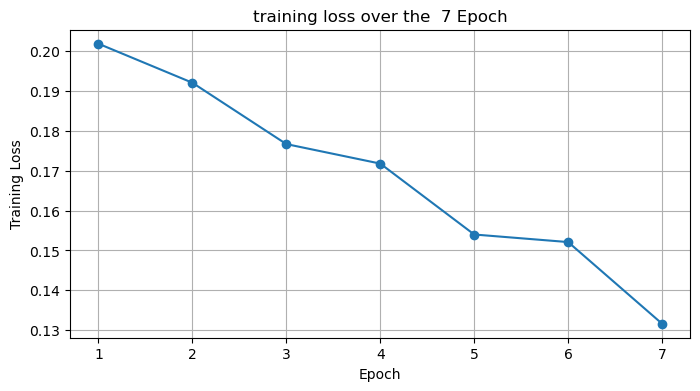

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df['Epoch'], df['Training Loss'], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('training loss over the  7 Epoch')
plt.grid(True)
plt.show()

#### Training Loss

 1. Calculated on the training dataset


#### validation loss over the epoches

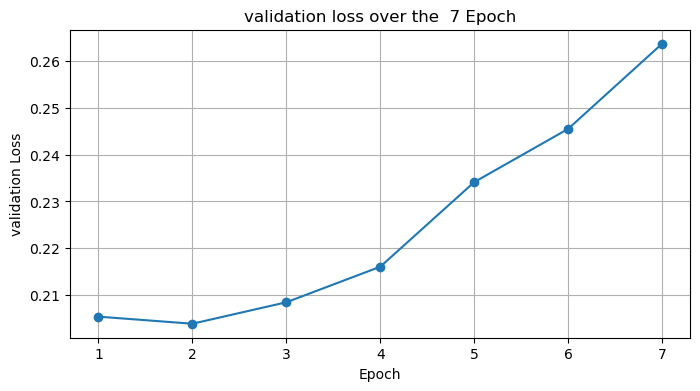

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(df['Epoch'], df['Validation Loss'], marker='o')
plt.xlabel('Epoch')
plt.ylabel('validation Loss')
plt.title('validation loss over the  7 Epoch')
plt.grid(True)
plt.show()

2. Calculated on unseen data (validation set)
        When it goes down the Model is learning well on unseen data
        When Validation Loss goes down:

    Model is learning well on unseen data

        When Validation Loss goes up while training loss goes down:

        Overfitting begins
    In the  model:

    Training Loss goes down
    Validation Loss goes up (after epoch 4)

    This tells us  RoBERTa model started overfitting after epoch 4.

#### Macro F1 & Micro F1


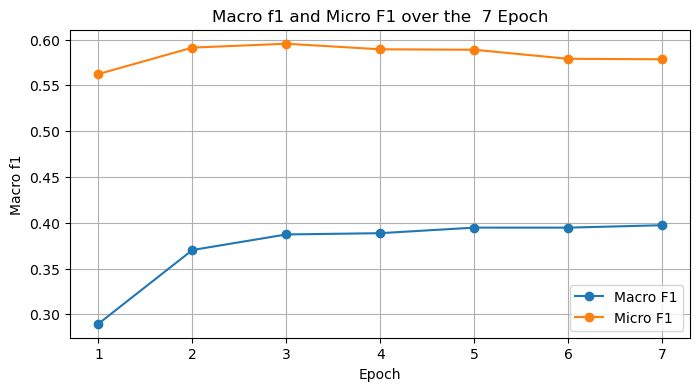

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(df['Epoch'], df[['Macro F1',"Micro F1"]], marker='o' ,label=['Macro F1', 'Micro F1'])
plt.xlabel('Epoch')
plt.ylabel('Macro f1')
plt.title('Macro f1 and Micro F1 over the  7 Epoch')
plt.grid(True)
plt.legend()
plt.show()

3. 
    Macro F1 — Treats all classes equally

        It Calculates F1 score for each emotion/label
        Then takes the average
        it is good for imbalanced data
4. Micro F1 — Treats every prediction equally

        It counts ALL true positives, false positives, false negatives then computes F1 using these totals

    Micro-F1 = overall performance across all labels

    Good for multi-label tasks

    Good when dataset is imbalanced
5.3. Hamming Loss
    The fraction of labels the model gets wrong.    


#### Scatter plot 



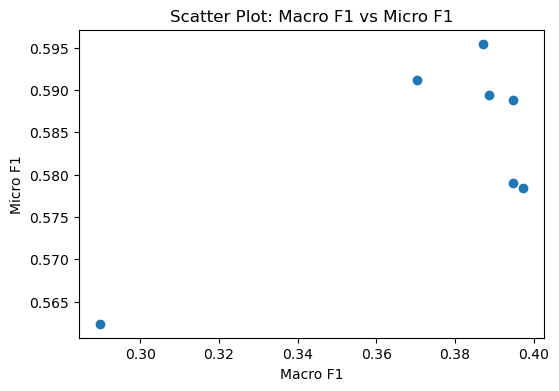

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(df["Macro F1"], df["Micro F1"])
plt.xlabel("Macro F1")
plt.ylabel("Micro F1")
plt.title("Scatter Plot: Macro F1 vs Micro F1")

plt.show()